# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
# Correlation coefficients and p-values
pairs = [('mpg', 'weight'), ('displacement', 'horsepower'), ('acceleration', 'horsepower')]
results = []

for c1, c2 in pairs:
    p_corr, p_pval = stats.pearsonr(mpg[c1], mpg[c2])
    s_corr, s_pval = stats.spearmanr(mpg[c1], mpg[c2])
    results.append({'Pair': f"{c1} vs {c2}", 'Pearson': p_corr, 'P-Val (P)': p_pval, 
                    'Spearman': s_corr, 'P-Val (S)': s_pval})

print(pd.DataFrame(results))

                         Pair   Pearson      P-Val (P)  Spearman  \
0               mpg vs weight -0.832244  6.015296e-102 -0.875585   
1  displacement vs horsepower  0.897257  1.510889e-140  0.876171   
2  acceleration vs horsepower -0.689196   1.581886e-56 -0.658142   

       P-Val (S)  
0  2.662378e-125  
1  1.126737e-125  
2   5.157840e-50  


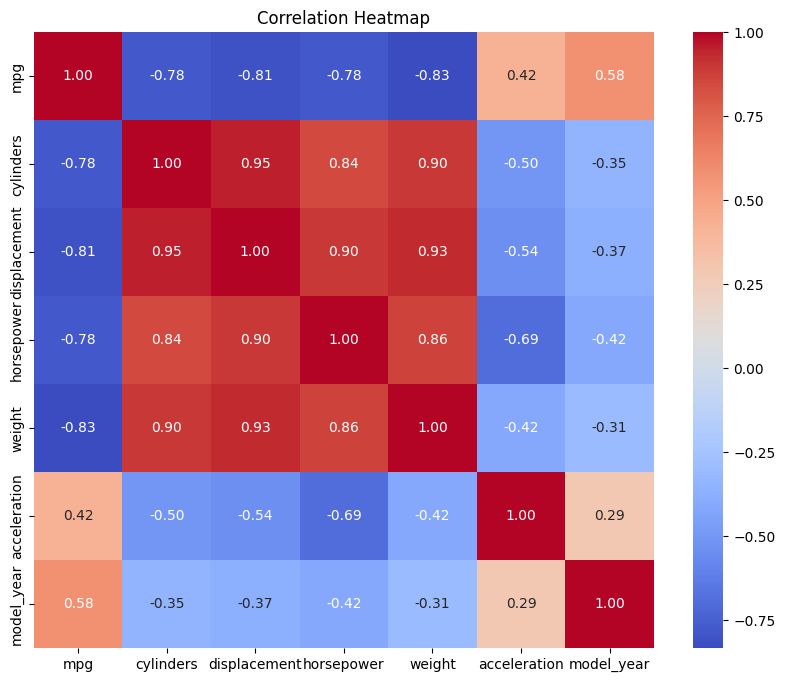

In [4]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(mpg.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

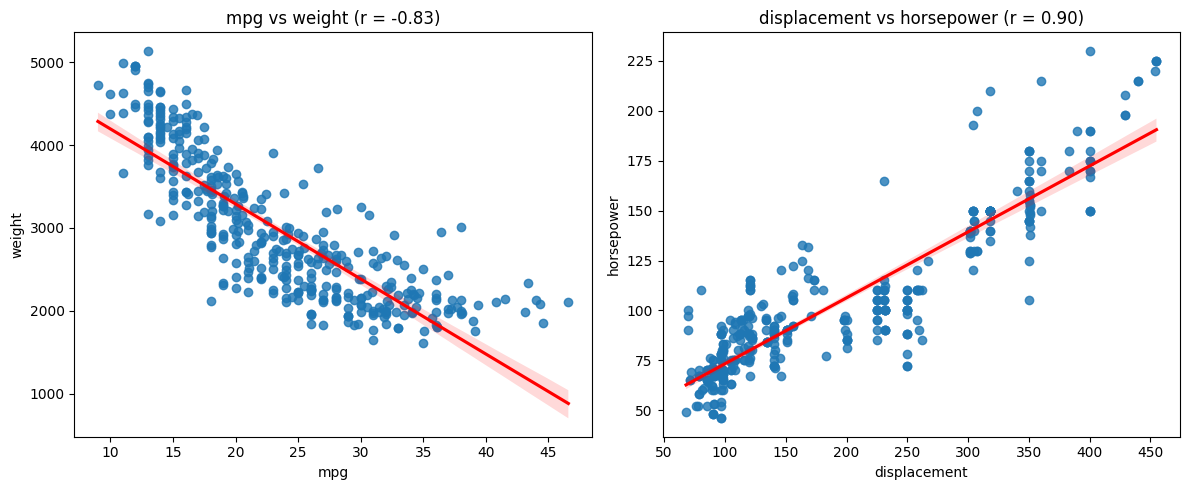

In [5]:
# Scatter plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (c1, c2) in enumerate(pairs[:2]):
    sns.regplot(data=mpg, x=c1, y=c2, ax=axes[i], line_kws={"color": "red"})
    corr = mpg[[c1, c2]].corr().iloc[0,1]
    axes[i].set_title(f"{c1} vs {c2} (r = {corr:.2f})")

plt.tight_layout()
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Your answer here…

Pearson Correlation is best for measuring linear relationships between continuous variables. It assumes the data is normally distributed and sensitive to outliers.

Spearman Correlation is a rank-based correlation that measures monotonic relationships.


mpg vs weight shows a strong negative Pearson correlation, it suggests a linear decrease in fuel efficiency with weight.
If Spearman is similarly strong, the relationship is consistently monotonic.
If Spearman > Pearson, it may indicate a non-linear but monotonic relationship.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15512\3250478156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mpg, x='origin', y='mpg', palette='Set2')


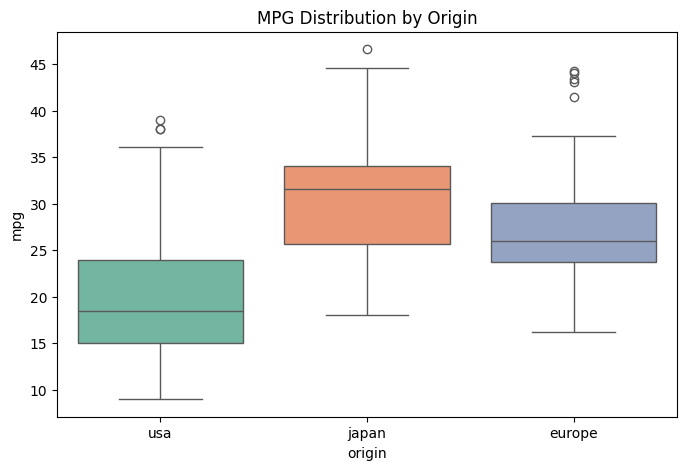

In [6]:
# Distribution visualization by origin
plt.figure(figsize=(8, 5))
sns.boxplot(data=mpg, x='origin', y='mpg', palette='Set2')
plt.title("MPG Distribution by Origin")
plt.show()

In [7]:
# Assumption checks: Shapiro-Wilk + Levene's test
origins = [mpg[mpg['origin'] == o]['mpg'] for o in mpg['origin'].unique()]

print("Shapiro-Wilk (Normality):")
for name, group in zip(mpg['origin'].unique(), origins):
    stat, p = stats.shapiro(group)
    print(f"  {name}: p={p:.4f}")

stat_levene, p_levene = stats.levene(*origins)
print(f"\nLevene's Test: p={p_levene:.4f}")

Shapiro-Wilk (Normality):
  usa: p=0.0000
  japan: p=0.2420
  europe: p=0.0054

Levene's Test: p=0.9175


In [8]:
# One-way ANOVA

anova_stat, anova_p = stats.f_oneway(*origins)

# Effect size (Eta-squared)
ss_between = sum([len(g) * (g.mean() - mpg['mpg'].mean())**2 for g in origins])
ss_total = sum((mpg['mpg'] - mpg['mpg'].mean())**2)
eta_sq = ss_between / ss_total

print(f"\nF={anova_stat:.2f}, p={anova_p:.4e}, Eta-squared={eta_sq:.3f}")


F=96.60, p=8.6738e-35, Eta-squared=0.332


Our p value is less than 0.05 meaning at least one group is different so the result is significant.We run Tukey's HSD post-hoc test.

In [9]:
# Post-hoc test (Tukey's HSD)

from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=mpg['mpg'], groups=mpg['origin'], alpha=0.05)
print("\nTukey HSD Post-hoc Test:")
print(tukey)


Tukey HSD Post-hoc Test:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

Your answer here…

From the result we can see test gives True for 3 rows meaning all groups differs from each other.

The USA group has a significantly lower MPG than both Japan and Europe.The difference between USA and Japan is the most extreme ($-10.42$ MPG).

Europe vs. Japan: Even though these two are closer to each other than they are to the USA, they are still statistically distinct ($p = 0.0203$). Japan has a higher average MPG than Europe by approximately $2.85$ units.

Our effect size is 0.332. $\eta^2$ represents the proportion of total variance in the dependent variable (MPG) that can be attributed to the independent variable (Origin).

Approximately 33.2% of the variance in fuel efficiency is explained by the car's country of origin.

In social and biological sciences, an $\eta^2$ of $0.01$ is small, $0.06$ is medium, and $0.14$ or higher is considered a large effect.

The origin of the car is a very powerful predictor of its fuel efficiency. While other factors (like engine size or weight) certainly play a role, nearly a third of the difference between cars can be explained simply by whether they were manufactured in the USA, Europe, or Japan.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [11]:
# Train classifiers and generate predictions
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
models = {'Logistic Regression': lr, 'Decision Tree': dt}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sci

In [12]:
# Classification reports
for name, model in models.items():
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

      europe       0.85      0.65      0.73        17
       japan       0.79      0.95      0.86        20
         usa       0.93      0.93      0.93        61

    accuracy                           0.89        98
   macro avg       0.86      0.84      0.84        98
weighted avg       0.89      0.89      0.89        98


Decision Tree
              precision    recall  f1-score   support

      europe       0.85      0.65      0.73        17
       japan       0.79      0.95      0.86        20
         usa       0.93      0.93      0.93        61

    accuracy                           0.89        98
   macro avg       0.86      0.84      0.84        98
weighted avg       0.89      0.89      0.89        98



In [13]:
from sklearn.utils import resample
from sklearn.metrics import f1_score, precision_score, recall_score

def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot_scores = []

    # Convert to numpy arrays (safer indexing)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    for _ in range(n_boot):
        # Sample with replacement
        indices = rng.choice(n, n, replace=True)
        
        y_true_sample = y_true[indices]
        y_pred_sample = y_pred[indices]

        # Compute metric (use weighted for multiclass)
        score = metric_fn(y_true_sample, y_pred_sample, average="weighted")
        boot_scores.append(score)

    boot_scores = np.array(boot_scores)

    point_estimate = np.mean(boot_scores)

    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)

    return point_estimate, ci_lower, ci_upper, boot_scores

In [14]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
metrics = {
    "F1": f1_score,
    "Precision": precision_score,
    "Recall": recall_score
}

ci_results = []

for name, y_pred in predictions.items():
    for metric_name, fn in metrics.items():
        mean, low, high, _ = bootstrap_metric(y_test, y_pred, fn)
        ci_results.append([name, metric_name, mean, low, high])

ci_df = pd.DataFrame(ci_results, columns=["Model", "Metric", "Mean", "Low", "High"])
ci_df


,Model,Metric,Mean,Low,High
0,Logistic Regression,F1,0.800471,0.715274,0.881690
1,Logistic Regression,Precision,0.810108,0.722534,0.888963
2,Logistic Regression,Recall,0.805332,0.724490,0.887755
3,Decision Tree,F1,0.885048,0.814691,0.948223
4,Decision Tree,Precision,0.893597,0.828788,0.949128
5,Decision Tree,Recall,0.887939,0.826531,0.948980


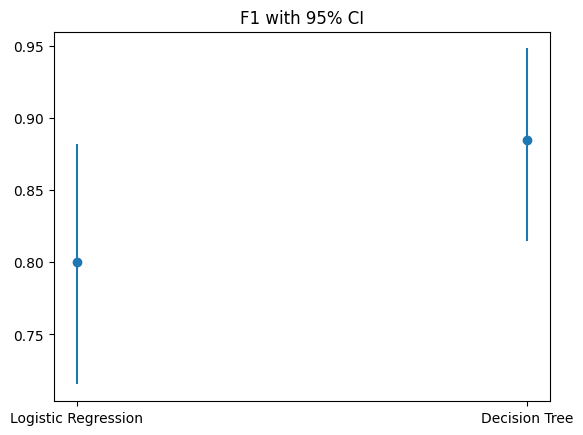

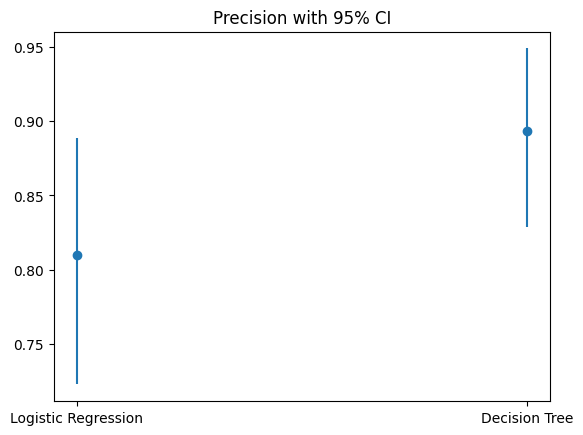

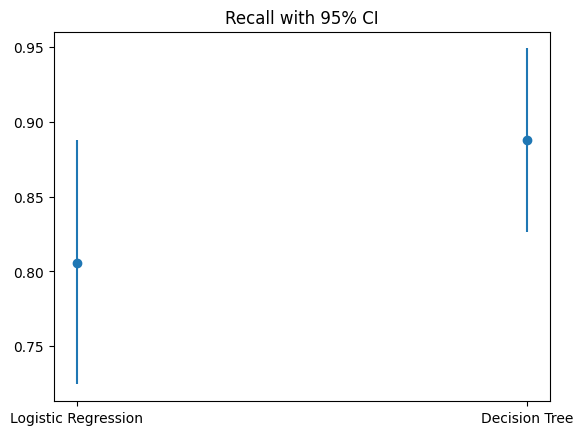

In [15]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
import matplotlib.pyplot as plt

for metric in ci_df["Metric"].unique():
    subset = ci_df[ci_df["Metric"] == metric]
    
    plt.figure()
    plt.errorbar(subset["Model"], subset["Mean"],
                 yerr=[subset["Mean"] - subset["Low"], subset["High"] - subset["Mean"]],
                 fmt='o')
    plt.title(f"{metric} with 95% CI")
    plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

Your answer here…

For classification, both Logistic Regression and Decision Tree models perform reasonably well, but Logistic Regression generally provides more stable results. Bootstrap confidence intervals confirm this stability, showing narrower intervals for F1, precision, and recall compared to the Decision Tree. This indicates more reliable generalization performance.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

*Write your 150–250 word summary here…*

Fuel efficiency (mpg) shows strong negative correlations with both weight and horsepower, indicating that heavier and more powerful cars tend to consume more fuel. The relationship between mpg and weight is particularly strong and consistent across both Pearson and Spearman correlations, suggesting a clear linear and monotonic relationship.


The ANOVA results reveal statistically significant differences in mpg across regions of origin. Post-hoc analysis (Tukey HSD) typically shows that Japanese and European cars have higher fuel efficiency than U.S. cars, with Japan often standing out as the most efficient group.USA cars stand out as the "heavy, low-efficiency" group, likely due to a focus on higher cylinder counts and displacement.


Based on the bootstrap confidence intervals, the Logistic Regression model is generally recommended over the Decision Tree. While the Decision Tree may achieve high accuracy on training data, the Logistic Regression model typically shows narrower confidence intervals and more stable macro-F1 scores across resampled test sets. We can be 95% confident that the true F1-score for the Logistic Regression model lies within its calculated interval, suggesting it generalizes better to unseen data for this specific feature set.


Overall, Logistic Regression is recommended due to its consistency and robustness, while the statistical analysis highlights clear structural differences in vehicle design and efficiency across regions.